# Sentiment Panel Regression

Tests whether aggregated forum sentiment predicts stock returns. Lag window and target return horizon are matched — weekly sentiment predicts next-week returns, etc.

In [1]:
import pandas as pd
import numpy as np
from linearmodels import PanelOLS, PooledOLS
from linearmodels.panel import RandomEffects
from pathlib import Path

## Config

| `LAG_WINDOW` | Sentiment window | Target return |
|---|---|---|
| `'daily'` | posts on day D-1 | return on day D |
| `'weekly'` | mean of posts in week W-1 | compound return in week W |
| `'monthly'` | mean of posts in month M-1 | compound return in month M |


In [2]:
LAG_WINDOW          = 'monthly'   # 'daily' | 'weekly' | 'monthly'
NULL_STRATEGY       = 'drop'

PANEL_DATA_PATH  = Path('./data/panel_data.parquet')
SENTIMENT_PATH   = Path('../sentiment/data/all_labeled_finnishbert.parquet')
FORUM_POSTS_PATH = Path('../sentiment/data/cleaned_forum_posts.parquet')

print(f'LAG_WINDOW          : {LAG_WINDOW}')

LAG_WINDOW          : monthly


## Load Data

In [3]:
stock_daily = pd.read_parquet(PANEL_DATA_PATH)
stock_daily['Date'] = pd.to_datetime(stock_daily['Date'])
if 'prev_day_sentiment' in stock_daily.columns:
    stock_daily = stock_daily.drop(columns=['prev_day_sentiment'])

sentiment   = pd.read_parquet(SENTIMENT_PATH,   columns=['id', 'sentiment'])
forum_posts = pd.read_parquet(FORUM_POSTS_PATH, columns=['id', 'date_time', 'ticker'])

print(f'Stock rows : {len(stock_daily):,}  |  tickers: {stock_daily["ticker"].nunique()}')
print(f'Sentiment  : {len(sentiment):,}')

Stock rows : 390,127  |  tickers: 162
Sentiment  : 532,424


## Resample Stock Data & Compute Controls

For weekly/monthly specs, daily returns are compounded into period returns and control variables are aggregated to the same frequency. Daily-lag controls (`return_lag1/2/5`) are replaced by a single `return_lag_period` computed from the resampled panel.

In [4]:
# Column classification for aggregation
COMPOUND_COLS = [
    'return',
    'open_to_close_return', 'close_to_open_return',
    'EURUSD_return', 'EURSEK_return', 'EURCNY_return',
    'GC_return', 'CL_return', 'VIX_return', 'GSPC_return', 'TNX_return',
    'OMXHPI_return', 'OMXN40_return', 'STOXX50E_return',
]
SUM_COLS  = ['euribor_3m_diff', 'finland_10y_diff']
MEAN_COLS = ['log_volume', 'gk_vol', 'momentum_12_1', 'amihud']
LAST_COLS = ['unemp_rate_change_lagged', 'cpi_rate_change_lagged', 'consumer_conf_change_lagged']

def compound(s):
    valid = s.dropna()
    return (1 + valid).prod() - 1 if len(valid) else np.nan


def resample_stock(df, period):
    """Resample daily panel to weekly or monthly frequency."""
    df = df.copy()
    if period == 'weekly':
        # Period key = Monday of the trading week
        df['_period'] = df['Date'] - pd.to_timedelta(df['Date'].dt.weekday, unit='D')
    else:  # monthly
        df['_period'] = df['Date'].dt.to_period('M').dt.to_timestamp()

    present = set(df.columns)
    agg = {}
    for c in COMPOUND_COLS:
        if c in present: agg[c] = compound
    for c in SUM_COLS:
        if c in present: agg[c] = 'sum'
    for c in MEAN_COLS:
        if c in present: agg[c] = 'mean'
    for c in LAST_COLS:
        if c in present: agg[c] = 'last'

    result = (
        df.groupby(['ticker', '_period'])
        .agg(agg)
        .reset_index()
        .rename(columns={'_period': 'Date'})
    )
    # Lagged period return replaces daily return_lag1/2/5
    result = result.sort_values(['ticker', 'Date'])
    result['return_lag_period'] = result.groupby('ticker')['return'].shift(1)
    return result


if LAG_WINDOW == 'daily':
    df_stock = stock_daily.copy()
    PERIOD_CONTROLS = [
        'return_lag1', 'return_lag2', 'return_lag5',
        'log_volume', 'gk_vol', 'momentum_12_1', 'amihud',
        'open_to_close_return', 'close_to_open_return',
        'EURUSD_return', 'EURSEK_return', 'EURCNY_return',
        'GC_return', 'CL_return', 'VIX_return', 'GSPC_return', 'TNX_return',
        'euribor_3m_diff', 'OMXHPI_return', 'OMXN40_return', 'STOXX50E_return',
        'finland_10y_diff', 'unemp_rate_change_lagged',
        'cpi_rate_change_lagged', 'consumer_conf_change_lagged',
    ]
else:
    df_stock = resample_stock(stock_daily, LAG_WINDOW)
    PERIOD_CONTROLS = [
        'return_lag_period',
        'log_volume', 'gk_vol', 'momentum_12_1', 'amihud',
        'open_to_close_return', 'close_to_open_return',
        'EURUSD_return', 'EURSEK_return', 'EURCNY_return',
        'GC_return', 'CL_return', 'VIX_return', 'GSPC_return', 'TNX_return',
        'euribor_3m_diff', 'OMXHPI_return', 'OMXN40_return', 'STOXX50E_return',
        'finland_10y_diff', 'unemp_rate_change_lagged',
        'cpi_rate_change_lagged', 'consumer_conf_change_lagged',
    ]

print(f'Resampled stock shape: {df_stock.shape}')
print(f'Period range: {df_stock["Date"].min().date()} — {df_stock["Date"].max().date()}')

Resampled stock shape: (19099, 26)
Period range: 2012-01-01 — 2025-12-01


## Compute Sentiment Variable

In [5]:
# Attach date + ticker to each label
sent_dated = sentiment.merge(forum_posts, on='id', how='inner')
sent_dated['Date'] = sent_dated['date_time'].dt.normalize()

# Daily mean sentiment per (ticker, calendar day)
daily_sent = (
    sent_dated
    .groupby(['ticker', 'Date'])['sentiment']
    .mean()
    .reset_index()
)

if LAG_WINDOW == 'daily':
    # Infer trading days from panel data: any weekday missing stock rows is
    # treated as a holiday (covers Easter, Independence Day, etc.).
    trading_days = np.sort(df_stock['Date'].unique())  # sorted datetime64 array

    # Map each post date to the next trading day *strictly after* it.
    # This absorbs weekend/holiday posts into the following trading day's
    # lag window rather than dropping them.
    #   e.g. Fri/Sat/Sun posts → all attributed to Monday's sentiment_var
    post_dates = daily_sent['Date'].values
    idx = np.searchsorted(trading_days, post_dates, side='right')
    valid = idx < len(trading_days)
    idx_clipped = np.minimum(idx, len(trading_days) - 1)
    daily_sent['next_trading_day'] = pd.to_datetime(
        np.where(valid, trading_days[idx_clipped], pd.NaT)
    )

    # Drop posts that fall after the last trading day in the dataset
    daily_sent = daily_sent.dropna(subset=['next_trading_day'])

    # Aggregate: all posts in the lag window [prev_trading_day+1 … D-1] → D
    lag_sent = (
        daily_sent
        .groupby(['ticker', 'next_trading_day'])['sentiment']
        .mean()
        .reset_index()
        .rename(columns={'next_trading_day': 'Date'})
    )

    # Merge onto trading-day grid; no shift needed — attribution is already lagged
    all_dates = df_stock[['ticker', 'Date']].drop_duplicates()
    daily_sent = all_dates.merge(lag_sent, on=['ticker', 'Date'], how='left')
    daily_sent['sentiment_var'] = daily_sent['sentiment']

    n_on_nontrading = (~np.isin(post_dates, trading_days) & valid).sum()
    print(f'Trading days inferred : {len(trading_days):,}')
    print(f'Posts on non-trading days absorbed: {n_on_nontrading:,}')

else:
    # Aggregate posts to the same period key used in df_stock
    if LAG_WINDOW == 'weekly':
        daily_sent['_period'] = daily_sent['Date'] - pd.to_timedelta(daily_sent['Date'].dt.weekday, unit='D')
    else:  # monthly
        daily_sent['_period'] = daily_sent['Date'].dt.to_period('M').dt.to_timestamp()

    period_sent = (
        daily_sent
        .groupby(['ticker', '_period'])['sentiment']
        .mean()
        .reset_index()
        .rename(columns={'_period': 'Date'})
    )

    # Merge onto period stock grid, then shift 1 period
    all_periods = df_stock[['ticker', 'Date']].drop_duplicates()
    period_sent = all_periods.merge(period_sent, on=['ticker', 'Date'], how='left')
    period_sent = period_sent.sort_values(['ticker', 'Date'])
    period_sent['sentiment_var'] = (
        period_sent
        .groupby('ticker')['sentiment']
        .transform(lambda s: s.shift(1))  # period P-1 sentiment predicts period P return
    )
    daily_sent = period_sent

# Apply null strategy
if NULL_STRATEGY == 'neutral':
    daily_sent['sentiment_var'] = daily_sent['sentiment_var'].fillna(1.0)
elif NULL_STRATEGY == 'forward_fill':
    daily_sent['sentiment_var'] = (
        daily_sent.groupby('ticker')['sentiment_var']
        .transform(lambda s: s.ffill())
    )
# 'drop' — leave NaN; handled by dropna() in panel prep

coverage = daily_sent['sentiment_var'].notna().mean()
print(f'Sentiment coverage after "{NULL_STRATEGY}" strategy: {coverage:.1%}')
print(daily_sent['sentiment_var'].describe())

Sentiment coverage after "drop" strategy: 60.4%
count    11544.000000
mean         1.229540
std          0.476722
min          0.000000
25%          1.000000
50%          1.250000
75%          1.527778
max          2.000000
Name: sentiment_var, dtype: float64


## Build Panel Dataset

In [6]:
df = df_stock.merge(
    daily_sent[['ticker', 'Date', 'sentiment_var']],
    on=['ticker', 'Date'], how='left'
)

analysis_vars = ['return', 'sentiment_var'] + PERIOD_CONTROLS


df_panel = df.dropna(subset=analysis_vars)

df_panel = df_panel[['ticker', 'Date'] + analysis_vars].copy()
df_panel['const'] = 1.0  # explicit intercept for PooledOLS
df_panel = df_panel.set_index(['ticker', 'Date'])

print(f'Panel rows : {len(df_panel):,}')
print(f'Tickers    : {df_panel.index.get_level_values(0).nunique()}')
print(f'Periods    : {df_panel.index.get_level_values(1).nunique()}')

Panel rows : 10,997
Tickers    : 154
Periods    : 155


## 1. Pooled OLS (Baseline)

## 1b. Hausman Test (FE vs RE)

In [7]:
exog_vars       = ['sentiment_var'] + PERIOD_CONTROLS
exog_vars_const = ['const'] + exog_vars  # PooledOLS needs explicit intercept

re_results = RandomEffects(df_panel['return'], df_panel[exog_vars]).fit(
    cov_type='unadjusted'  # Hausman requires unadjusted (classical) SEs on both models
)
fe_hausman = PanelOLS(df_panel['return'], df_panel[exog_vars], entity_effects=True).fit(
    cov_type='unadjusted'
)

# Hausman statistic: H = (b_FE - b_RE)' * [Var(b_FE) - Var(b_RE)]^-1 * (b_FE - b_RE)
# Under H0 (RE consistent & efficient), H ~ chi2(k)
b_fe = fe_hausman.params.values
b_re = re_results.params[fe_hausman.params.index].values

v_fe = fe_hausman.cov.values
v_re = re_results.cov.loc[fe_hausman.params.index, fe_hausman.params.index].values

diff = b_fe - b_re
v_diff = v_fe - v_re

try:
    import numpy.linalg as la
    H = float(diff @ la.pinv(v_diff) @ diff)
    k = len(diff)
    from scipy import stats
    p_hausman = float(1 - stats.chi2.cdf(H, df=k))

    print('=' * 60)
    print('HAUSMAN TEST  (H0: RE is consistent — use RE)')
    print('=' * 60)
    print(f'Chi2 statistic : {H:.4f}')
    print(f'Degrees of freedom: {k}')
    print(f'p-value        : {p_hausman:.4f}')
    if p_hausman < 0.05:
        print('Verdict: Reject H0 → FE preferred (entity effects correlated with regressors)')
    else:
        print('Verdict: Fail to reject H0 → RE may be appropriate')
except np.linalg.LinAlgError as e:
    print(f'Hausman test failed (singular variance matrix): {e}')

print()
print('RE model summary (for reference):')
print(re_results.summary)

HAUSMAN TEST  (H0: RE is consistent — use RE)
Chi2 statistic : 392.8985
Degrees of freedom: 24
p-value        : 0.0000
Verdict: Reject H0 → FE preferred (entity effects correlated with regressors)

RE model summary (for reference):
                        RandomEffects Estimation Summary                        
Dep. Variable:                 return   R-squared:                        0.9649
Estimator:              RandomEffects   R-squared (Between):              0.9317
No. Observations:               10997   R-squared (Within):               0.9655
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.9643
Time:                        19:25:10   Log-likelihood                 2.689e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   1.257e+04
Entities:                         154   P-value                           0.0000
Avg Obs:                       71.409  

In [8]:
pooled_results = PooledOLS(df_panel['return'], df_panel[exog_vars_const]).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('POOLED OLS (Baseline — No Panel Effects)')
print('=' * 80)
print(pooled_results.summary)

POOLED OLS (Baseline — No Panel Effects)
                          PooledOLS Estimation Summary                          
Dep. Variable:                 return   R-squared:                        0.9645
Estimator:                  PooledOLS   R-squared (Between):              0.9369
No. Observations:               10997   R-squared (Within):               0.9657
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.9645
Time:                        19:25:10   Log-likelihood                 2.679e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.241e+04
Entities:                         154   P-value                           0.0000
Avg Obs:                       71.409   Distribution:                F(24,10972)
Min Obs:                       1.0000                                           
Max Obs:                       153.00   F-statistic (robust):       

## 2. Entity Fixed Effects

In [9]:
fe_results = PanelOLS(df_panel['return'], df_panel[exog_vars], entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('ENTITY FIXED EFFECTS')
print('=' * 80)
print(fe_results.summary)

# Wooldridge-style test for serial autocorrelation in panel residuals
import statsmodels.formula.api as smf
resid = fe_results.resids.rename('resid')
resid_lag = resid.groupby(level='ticker').shift(1).rename('resid_lag')
resid_df = pd.concat([resid, resid_lag], axis=1).dropna().reset_index()
wr = smf.ols('resid ~ resid_lag', data=resid_df).fit(
    cov_type='cluster', cov_kwds={'groups': resid_df['ticker']}
)
print('\nWooldridge-style autocorrelation test (H0: no serial autocorrelation):')
print(f'  coef(resid_lag) = {wr.params["resid_lag"]:.4f},  p = {wr.pvalues["resid_lag"]:.4f}  {"→ autocorrelation present" if wr.pvalues["resid_lag"] < 0.05 else "→ no evidence of autocorrelation"}')


ENTITY FIXED EFFECTS
                          PanelOLS Estimation Summary                           
Dep. Variable:                 return   R-squared:                        0.9661
Estimator:                   PanelOLS   R-squared (Between):             -1.9135
No. Observations:               10997   R-squared (Within):               0.9661
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.8313
Time:                        19:25:10   Log-likelihood                 2.713e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.285e+04
Entities:                         154   P-value                           0.0000
Avg Obs:                       71.409   Distribution:                F(24,10819)
Min Obs:                       1.0000                                           
Max Obs:                       153.00   F-statistic (robust):             3605.7
       

## 3. Two-Way Fixed Effects (Entity + Time)

In [10]:
fe_time_results = PanelOLS(
    df_panel['return'], df_panel[exog_vars],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

print('=' * 80)
print('TWO-WAY FIXED EFFECTS (Entity + Time FE)')
print('=' * 80)
print(fe_time_results.summary)

TWO-WAY FIXED EFFECTS (Entity + Time FE)
                          PanelOLS Estimation Summary                           
Dep. Variable:                 return   R-squared:                        0.9601
Estimator:                   PanelOLS   R-squared (Between):             -24.632
No. Observations:               10997   R-squared (Within):              -0.9120
Date:                Wed, Apr 15 2026   R-squared (Overall):             -1.7178
Time:                        19:25:11   Log-likelihood                 2.725e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.167e+04
Entities:                         154   P-value                           0.0000
Avg Obs:                       71.409   Distribution:                F(22,10667)
Min Obs:                       1.0000                                           
Max Obs:                       153.00   F-statistic (robust):       

/var/folders/vs/mq6j80s94v7_ts2x082jdx1w0000gn/T/ipykernel_35784/3403796528.py:4: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

unemp_rate_change_lagged, consumer_conf_change_lagged

  ).fit(cov_type='clustered', cluster_entity=True)


## 4. F-test for Entity Effects

In [11]:
from scipy import stats

# F-test for entity fixed effects (H0: Pooled OLS is adequate)
print('F-test for entity fixed effects:')
print('H0: Pooled OLS is appropriate (no entity effects)')
print('H1: Entity fixed effects are warranted')
try:
    f_stat = fe_results.f_pooled.stat
    f_pval = fe_results.f_pooled.pval
    print(f'  F-stat : {f_stat:.4f}')
    print(f'  p-value: {f_pval:.4f}')
    print('  Verdict:', 'Reject H0 — entity FE warranted' if f_pval < 0.05 else 'Fail to reject H0')
except Exception as e:
    print(f'  Could not compute F-test: {e}')

# F-test for time fixed effects (H0: Entity FE is sufficient, no time effects)
print('\nF-test for time fixed effects:')
print('H0: Entity FE is sufficient (no time effects)')
print('H1: Two-Way FE is warranted')
try:
    n      = fe_results.nobs
    k_extra = fe_time_results.df_model - fe_results.df_model
    rss_r  = fe_results.resid_ss
    rss_u  = fe_time_results.resid_ss
    denom_df = n - fe_time_results.df_model - 1
    f_time = ((rss_r - rss_u) / k_extra) / (rss_u / denom_df)
    p_time = stats.f.sf(f_time, k_extra, denom_df)
    print(f'  F-stat : {f_time:.4f}')
    print(f'  p-value: {p_time:.4f}')
    print('  Verdict:', 'Reject H0 — Two-Way FE warranted' if p_time < 0.05 else 'Fail to reject H0 — Entity FE sufficient')
except Exception as e:
    print(f'  Could not compute F-test: {e}')


F-test for entity fixed effects:
H0: Pooled OLS is appropriate (no entity effects)
H1: Entity fixed effects are warranted
  F-stat : 4.5096
  p-value: 0.0000
  Verdict: Reject H0 — entity FE warranted

F-test for time fixed effects:
H0: Entity FE is sufficient (no time effects)
H1: Two-Way FE is warranted
  F-stat : 1.5493
  p-value: 0.0000
  Verdict: Reject H0 — Two-Way FE warranted


## 5. Sentiment Dummies (Entity FE, two-way FE, ref = neutral)

In [12]:
df_dum = df_panel.copy()
df_dum['sent_negative'] = (df_dum['sentiment_var'] < 1).astype(float)
df_dum['sent_positive'] = (df_dum['sentiment_var'] > 1).astype(float)

exog_dummies = ['sent_negative', 'sent_positive'] + PERIOD_CONTROLS

fe_dummy_results = PanelOLS(df_dum['return'], df_dum[exog_dummies], entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('ENTITY FE — SENTIMENT DUMMIES (ref: neutral)')
print('=' * 80)
print(fe_dummy_results.summary)

fe_time_dummy_results = PanelOLS(
    df_dum['return'], df_dum[exog_dummies],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)
print('=' * 80)
print('TWO-WAY FE — SENTIMENT DUMMIES (ref: neutral)')
print('=' * 80)
print(fe_time_dummy_results.summary)

ENTITY FE — SENTIMENT DUMMIES (ref: neutral)
                          PanelOLS Estimation Summary                           
Dep. Variable:                 return   R-squared:                        0.9661
Estimator:                   PanelOLS   R-squared (Between):             -1.6467
No. Observations:               10997   R-squared (Within):               0.9661
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.8434
Time:                        19:25:11   Log-likelihood                 2.713e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.233e+04
Entities:                         154   P-value                           0.0000
Avg Obs:                       71.409   Distribution:                F(25,10818)
Min Obs:                       1.0000                                           
Max Obs:                       153.00   F-statistic (robust):   

/var/folders/vs/mq6j80s94v7_ts2x082jdx1w0000gn/T/ipykernel_35784/3793433435.py:18: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

unemp_rate_change_lagged, consumer_conf_change_lagged

  ).fit(cov_type='clustered', cluster_entity=True)


## 6. Piecewise Continuous Sentiment (Entity FE + Two-Way FE)

In [13]:
df_pw = df_panel.copy()
# Negative branch: intensity of negativity (0 when neutral/positive, up to 1 when fully negative)
df_pw['sent_neg_cont'] = np.where(df_pw['sentiment_var'] < 1, 1 - df_pw['sentiment_var'], 0.0)
# Positive branch: intensity of positivity (0 when neutral/negative, up to 1 when fully positive)
df_pw['sent_pos_cont'] = np.where(df_pw['sentiment_var'] > 1, df_pw['sentiment_var'] - 1, 0.0)

exog_pw = ['sent_neg_cont', 'sent_pos_cont'] + PERIOD_CONTROLS

fe_pw_results = PanelOLS(df_pw['return'], df_pw[exog_pw], entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('ENTITY FE — PIECEWISE CONTINUOUS SENTIMENT')
print('=' * 80)
print(fe_pw_results.summary)

fe_pw_time_results = PanelOLS(
    df_pw['return'], df_pw[exog_pw],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)
print('=' * 80)
print('TWO-WAY FE — PIECEWISE CONTINUOUS SENTIMENT')
print('=' * 80)
print(fe_pw_time_results.summary)


ENTITY FE — PIECEWISE CONTINUOUS SENTIMENT
                          PanelOLS Estimation Summary                           
Dep. Variable:                 return   R-squared:                        0.9661
Estimator:                   PanelOLS   R-squared (Between):             -1.7419
No. Observations:               10997   R-squared (Within):               0.9661
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.8390
Time:                        19:25:11   Log-likelihood                 2.713e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.233e+04
Entities:                         154   P-value                           0.0000
Avg Obs:                       71.409   Distribution:                F(25,10818)
Min Obs:                       1.0000                                           
Max Obs:                       153.00   F-statistic (robust):     

/var/folders/vs/mq6j80s94v7_ts2x082jdx1w0000gn/T/ipykernel_35784/2004601918.py:20: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

unemp_rate_change_lagged, consumer_conf_change_lagged

  ).fit(cov_type='clustered', cluster_entity=True)


## 7. Summary

In [14]:
def sig(p):
    if p is None: return 'n/a'
    return '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else 'n.s.'))

print('=' * 80)
print(f'SUMMARY  |  LAG: {LAG_WINDOW}  |  NULL: {NULL_STRATEGY} ')
print('=' * 80)

# Continuous sentiment_var
rows = []
if 'sentiment_var' in fe_time_results.params.index:
    p    = fe_time_results.params['sentiment_var']
    se   = fe_time_results.std_errors['sentiment_var']
    pval = fe_time_results.pvalues['sentiment_var']
    rows.append({'Model': 'Two-Way FE', 'Coef': round(p, 6), 'Std Err': round(se, 6),
                 'p-value': round(pval, 4), 'Sig': sig(pval)})
else:
    rows.append({'Model': 'Two-Way FE', 'Coef': None, 'Std Err': None,
                 'p-value': None, 'Sig': 'absorbed'})

print('Continuous sentiment_var:')
print(pd.DataFrame(rows).set_index('Model').to_string())

print('\nDummy model — Two-Way FE (ref=neutral):')
for var in ['sent_negative', 'sent_positive']:
    if var in fe_time_dummy_results.params.index:
        coef = fe_time_dummy_results.params[var]
        pval = fe_time_dummy_results.pvalues[var]
        print(f'  {var:15s}  coef={coef:.6f}  p={pval:.4f}  {sig(pval)}')
    else:
        print(f'  {var:15s}  absorbed by time FE')

print('\nPiecewise continuous — Two-Way FE:')
for var in ['sent_neg_cont', 'sent_pos_cont']:
    if var in fe_pw_time_results.params.index:
        coef = fe_pw_time_results.params[var]
        pval = fe_pw_time_results.pvalues[var]
        print(f'  {var:15s}  coef={coef:.6f}  p={pval:.4f}  {sig(pval)}')
    else:
        print(f'  {var:15s}  absorbed by time FE')

SUMMARY  |  LAG: monthly  |  NULL: drop 
Continuous sentiment_var:
                Coef   Std Err  p-value Sig
Model                                      
Two-Way FE  0.000922  0.000409   0.0241  **

Dummy model — Two-Way FE (ref=neutral):
  sent_negative    coef=-0.001568  p=0.0271  **
  sent_positive    coef=-0.000340  p=0.6007  n.s.

Piecewise continuous — Two-Way FE:
  sent_neg_cont    coef=-0.001629  p=0.0933  *
  sent_pos_cont    coef=0.000488  p=0.3470  n.s.


## ACF / PACF of TWFE Residuals

Visual inspection of autocorrelation structure in the Two-Way FE residuals.  
Residuals are averaged across entities per time period (Option A) to produce a single time series.

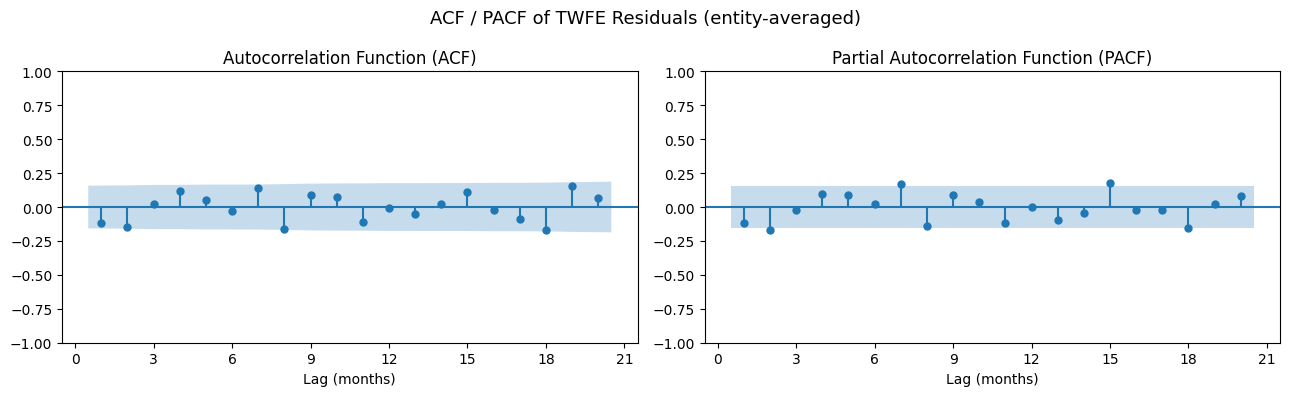

Time periods: 155, max lags plotted: 20


In [17]:
import statsmodels.graphics.tsaplots as tsaplots
import matplotlib.pyplot as plt

# Average TWFE residuals across entities per time period
resids = fe_time_results.resids
mean_resids = resids.groupby(level='Date').mean().sort_index()

n_periods = len(mean_resids)
max_lags = min(20, n_periods // 2 - 1)  # sensible lag limit for sample size

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('ACF / PACF of TWFE Residuals (entity-averaged)', fontsize=13)

tsaplots.plot_acf(mean_resids, lags=max_lags, ax=axes[0], alpha=0.05, zero=False)
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (months)')
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

tsaplots.plot_pacf(mean_resids, lags=max_lags, ax=axes[1], alpha=0.05, method='ywm', zero=False)
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (months)')
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

print(f'Time periods: {n_periods}, max lags plotted: {max_lags}')


## Robustness: Driscoll-Kraay Standard Errors

Driscoll-Kraay SEs are robust to heteroskedasticity, serial autocorrelation, and cross-sectional dependence (common shocks across firms). Reported alongside clustered SEs for comparison.

In [19]:
import numpy as np

# Bandwidth rule of thumb: floor(T^(1/4))
T = df_panel.index.get_level_values('Date').nunique()
bw = int(np.floor(T ** 0.25))
print(f'Time periods T={T}, Driscoll-Kraay bandwidth={bw}')

# --- TWFE: continuous sentiment ---
twfe_dk = PanelOLS(
    df_panel['return'], df_panel[exog_vars],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='driscoll-kraay', bandwidth=bw)

# --- TWFE: sentiment dummies ---
twfe_dum_dk = PanelOLS(
    df_dum['return'], df_dum[exog_dummies],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='driscoll-kraay', bandwidth=bw)

# --- TWFE: piecewise continuous sentiment ---
twfe_pw_dk = PanelOLS(
    df_pw['return'], df_pw[exog_pw],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='driscoll-kraay', bandwidth=bw)

# --- Comparison table ---
def compare_row(label, var, clustered, dk):
    if var not in clustered.params.index:
        return None
    return {
        'Model': label,
        'Variable': var,
        'Coef': round(clustered.params[var], 6),
        'SE (clustered)': round(clustered.std_errors[var], 6),
        'p (clustered)': round(clustered.pvalues[var], 4),
        'SE (DK)': round(dk.std_errors[var], 6),
        'p (DK)': round(dk.pvalues[var], 4),
    }

rows = [
    compare_row('TWFE continuous',  'sentiment_var',  fe_time_results,     twfe_dk),
    compare_row('TWFE dummies',     'sent_negative',  fe_time_dummy_results, twfe_dum_dk),
    compare_row('TWFE dummies',     'sent_positive',  fe_time_dummy_results, twfe_dum_dk),
    compare_row('TWFE piecewise',   'sent_neg_cont',  fe_pw_time_results,  twfe_pw_dk),
    compare_row('TWFE piecewise',   'sent_pos_cont',  fe_pw_time_results,  twfe_pw_dk),
]
rows = [r for r in rows if r is not None]

import pandas as pd
print('\nClustered vs Driscoll-Kraay SE comparison (TWFE models):')
print(pd.DataFrame(rows).to_string(index=False))


Time periods T=155, Driscoll-Kraay bandwidth=3


/var/folders/vs/mq6j80s94v7_ts2x082jdx1w0000gn/T/ipykernel_35784/1596197562.py:12: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

unemp_rate_change_lagged, consumer_conf_change_lagged

  ).fit(cov_type='driscoll-kraay', bandwidth=bw)
/var/folders/vs/mq6j80s94v7_ts2x082jdx1w0000gn/T/ipykernel_35784/1596197562.py:18: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

unemp_rate_change_lagged, consumer_conf_change_lagged

  ).fit(cov_type='driscoll-kraay', bandwidth=bw)



Clustered vs Driscoll-Kraay SE comparison (TWFE models):
          Model      Variable      Coef  SE (clustered)  p (clustered)  SE (DK)  p (DK)
TWFE continuous sentiment_var  0.000922        0.000409         0.0241 0.000398  0.0203
   TWFE dummies sent_negative -0.001568        0.000709         0.0271 0.000833  0.0597
   TWFE dummies sent_positive -0.000340        0.000650         0.6007 0.000739  0.6452
 TWFE piecewise sent_neg_cont -0.001629        0.000971         0.0933 0.001017  0.1092
 TWFE piecewise sent_pos_cont  0.000488        0.000519         0.3470 0.000700  0.4862


/var/folders/vs/mq6j80s94v7_ts2x082jdx1w0000gn/T/ipykernel_35784/1596197562.py:24: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

unemp_rate_change_lagged, consumer_conf_change_lagged

  ).fit(cov_type='driscoll-kraay', bandwidth=bw)
